# Wine Quality Analysis 

This project analyzes the UCI Wine Quality dataset. The goal is to loas and clean red and white wine data, analyze quality pattersn, create visualization, estimate wine quality using simple rule-based logic, and recommend similar wines based on user-provided prefrences. 

This project uses:
- Pandas for reading and processing CSV data
- NumPy for numerical calculations
- Matplotlib for graphing
- Pytest for testing project logic

This is the main program utilized to organize the project 

## Project Setup

This section imports the main dataset class and checks that the required data files are available. 

In [3]:
from pathlib import Path
from src.wine_dataset import WineDataset

# Store the expected dataset file paths in a dictionary
dataset_files = {
    "red": Path("data/winequality-red.csv"),
    "white": Path("data/winequality-white.csv")
}

# Check that both dataset files sxist before trying to load them
for wine_type, file_path in dataset_files.items():
    if file_path.exists():
        print(f"Found {wine_type} wine file: {file_path}")
    else:
        raise FileNotFoundError(f"Missing {wine_type} wine file: {file_path}")

Found red wine file: data/winequality-red.csv
Found white wine file: data/winequality-white.csv


## Load and Clean the Dataset

This section uses the 'WineDataset' class to load the red and white wine CSV files. The class checks required columns, removes duplicate rows, fills missing values if needed, and stores a cleaning summary. 

Included requirments:
- Data I/O by reading CSV files
- Class object creation
- Exception handling inside the class
- Loops and if statements inside the cleaning logic
- Mutable dictionaries/lists and immutable strings/tuples
- '__str__()' and '__len__'

In [5]:
import pandas as pd

# Create WineDataset objects for red and white wine
red_wine = WineDataset("data/winequality-red.csv", wine_type="red")
white_wine = WineDataset("data/winequality-white.csv", wine_type="white")

# Load and clean each dataset
red_cleaning_summary = red_wine.load_and_clean()
white_cleaning_summary = white_wine.load_and_clean()

# Display object summaries
print("Cleaned dataset objects:")
print(red_wine)
print(white_wine)

print("\nRed wine cleaning summary:")
print(red_cleaning_summary)

print("\nWhite wine cleaning summary:")
print(white_cleaning_summary)

print("\nRed wine quality counts:")
print(red_wine.get_quality_counts())

print("\nWhite wine quality counts:")
print(white_wine.get_quality_counts())

print("\nFirst five rows of cleaned red wine data:")
display(red_wine.data.head())

print('\nFirst five rows of cleaned white wine data:')
display(white_wine.data.head())

Cleaned dataset objects:
WineDataset(red wine, 1359 rows loaded)
WineDataset(white wine, 3961 rows loaded)

Red wine cleaning summary:
{'starting_rows': 1599, 'duplicates_removed': 240, 'missing_values_filled': 0, 'ending_rows': 1359}

White wine cleaning summary:
{'starting_rows': 4898, 'duplicates_removed': 937, 'missing_values_filled': 0, 'ending_rows': 3961}

Red wine quality counts:
{5: 577, 6: 535, 7: 167, 4: 53, 8: 17, 3: 10}

White wine quality counts:
{6: 1788, 5: 1175, 7: 689, 8: 131, 4: 153, 3: 20, 9: 5}

First five rows of cleaned red wine data:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5



First five rows of cleaned white wine data:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


## Analyze the Cleaned Dataset

This section uses the 'WineQualityAnalyzer' class to calculate summary statistics, compare red and white wine, group quality scores into catagories, and find top-quality wines.

Included requirments:
- Second meaningful class
- Composition relationship: 'WineQualityAnalyzer' uses a cleaned 'WineDataset'
- NumPy calculations
- Loops and if statements
- Mutable dictionaries/lists/sets
- '__eq__()' operator
- Set operations for comparing red and white wine quality scores
- 'map', 'zip', and 'lambda'

In [ ]:
import numpy as np
from src.wine_analyzer import WineQualityAnalyzer

# Create analyzer objects using the cleaned WineDataset objects
red_analyzer = WineQualityAnalyzer(red_wine)
white_analyzer = WineQualityAnalyzer(white_wine)

print(red_analyzer)
print(white_analyzer)

print("\nRed wine basic summary:")
print(red_analyzer.get_basic_summary())

print("\nWhite wine basic summary:")
print(white_analyzer.get_basic_summary())

print("\nRed wine quality categories:")
print(red_analyzer.count_quality_categories())

print("\nWhite wine quality categories:")
print(white_analyzer.count_quality_categories())

print("\nAverage alcohol by red wine quality score:")
print(red_analyzer.get_average_by_quality("alcohol"))

print("\nAverage alcohol by white wine quality score:")
print(white_analyzer.get_average_by_quality("alcohol"))

print("\nHigh-quality red wine feature summary:")
print(red_analyzer.get_high_quality_feature_summary())

print("\nHigh-quality white wine feature summary:")
print(white_analyzer.get_high_quality_feature_summary())

print("\nAverage quality comparison:")
print(red_analyzer.compare_average_quality(white_analyzer))

print("\nQuality score set comparison:")
print(red_analyzer.compare_quality_score_sets(white_analyzer))

print("\nSelected red wine feature averages using zip, map, and lambda:")
print(red_feature_averages)

print("\nSelected white wine feature averages using zip, map, and lambda:")
print(white_feature_averages)

print("\nTop 5 red wines:")
display(red_analyzer.get_top_wines(5))

print("\nTop 5 white wines:")
display(white_analyzer.get_top_wines(5))

WineQualityAnalyzer(red wine, 1359 rows)
WineQualityAnalyzer(white wine, 3961 rows)

Red wine basic summary:
{'wine_type': 'red', 'number_of_wines': 1359, 'average_quality': np.float64(5.62), 'average_alcohol': np.float64(10.43), 'highest_quality': 8, 'lowest_quality': 3}

White wine basic summary:
{'wine_type': 'white', 'number_of_wines': 3961, 'average_quality': np.float64(5.85), 'average_alcohol': np.float64(10.59), 'highest_quality': 9, 'lowest_quality': 3}

Red wine quality categories:
{'low': 63, 'medium': 1112, 'high': 184}

White wine quality categories:
{'low': 173, 'medium': 2963, 'high': 825}

Average alcohol by red wine quality score:
{3: np.float64(9.955), 4: np.float64(10.265), 5: np.float64(9.889), 6: np.float64(10.659), 7: np.float64(11.491), 8: np.float64(12.159)}

Average alcohol by white wine quality score:
{3: np.float64(10.345), 4: np.float64(10.198), 5: np.float64(9.864), 6: np.float64(10.646), 7: np.float64(11.516), 8: np.float64(11.88), 9: np.float64(12.18)}

Hi

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
588,5.0,0.42,0.24,2.0,0.060,19.0,50.0,0.99170,3.72,0.74,14.0,8
1269,5.5,0.49,0.03,1.8,0.044,28.0,87.0,0.99080,3.50,0.82,14.0,8
455,11.3,0.62,0.67,5.2,0.086,6.0,19.0,0.99880,3.22,0.69,13.4,8
1120,7.9,0.54,0.34,2.5,0.076,8.0,17.0,0.99235,3.20,0.72,13.1,8
390,5.6,0.85,0.05,1.4,0.045,12.0,88.0,0.99240,3.56,0.82,12.9,8



Top 5 white wines:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1605,7.1,0.26,0.49,2.2,0.032,31.0,113.0,0.99030,3.37,0.42,12.9,9
876,6.9,0.36,0.34,4.2,0.018,57.0,119.0,0.98980,3.28,0.36,12.7,9
827,7.4,0.24,0.36,2.0,0.031,27.0,139.0,0.99055,3.28,0.48,12.5,9
820,6.6,0.36,0.29,1.6,0.021,24.0,85.0,0.98965,3.41,0.61,12.4,9
774,9.1,0.27,0.45,10.6,0.035,28.0,124.0,0.99700,3.20,0.46,10.4,9



Quality scores shared by red and white wine:
{3, 4, 5, 6, 7, 8}

Selected red wine feature averages using zip, map, and lambda:
{'alcohol': np.float64(10.432), 'pH': np.float64(3.31), 'sulphates': np.float64(0.659)}


# Visualize the Results

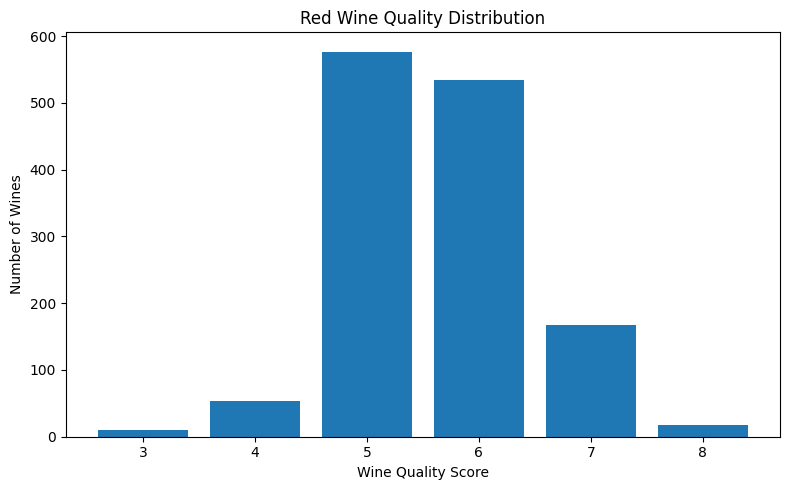

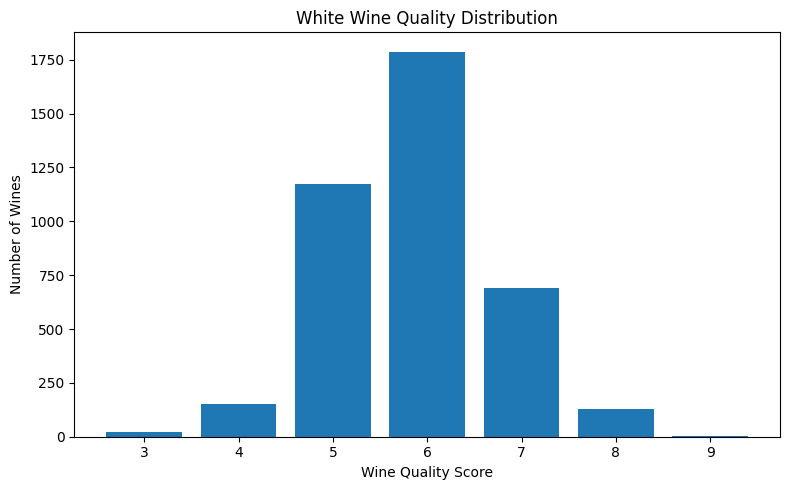

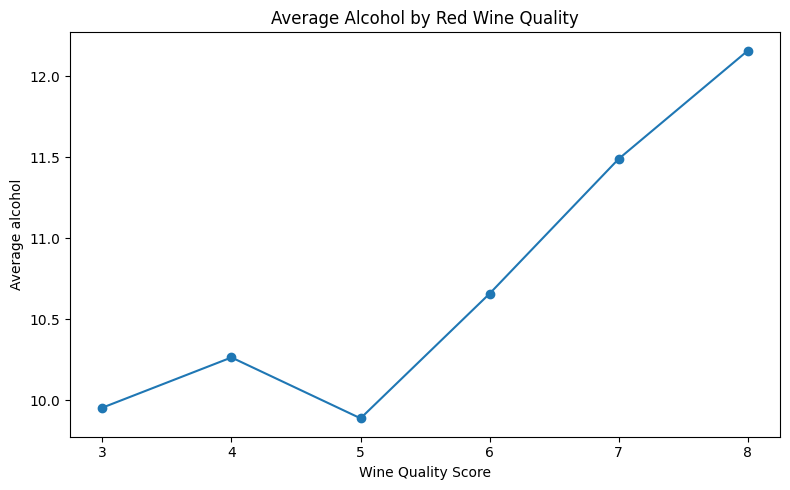

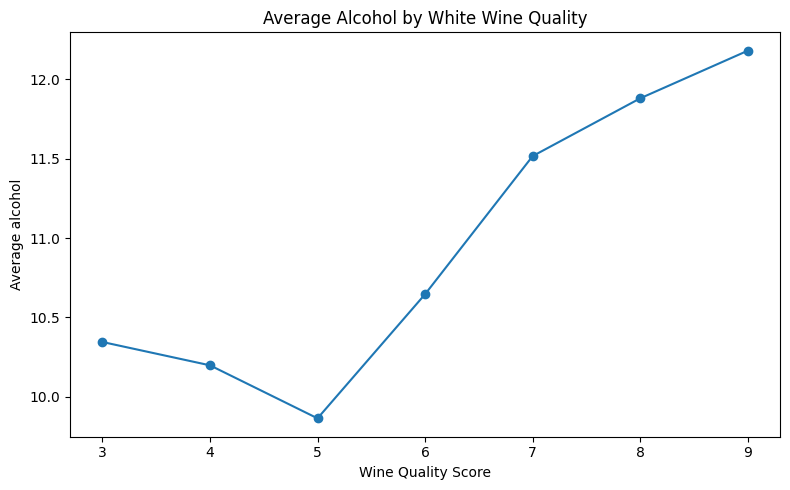

Saved graph files:
figures/red_quality_distribution.png
figures/white_quality_distribution.png
figures/red_alcohol_by_quality.png
figures/white_alcohol_by_quality.png


In [4]:
from src.wine_visuals import plot_quality_distribution, plot_average_by_quality

# Create quality distribution graphs.
red_quality_graph = plot_quality_distribution(red_analyzer)
white_quality_graph = plot_quality_distribution(white_analyzer)

# Create graphs showing how average alcohol changes by quality score.
red_alcohol_graph = plot_average_by_quality(red_analyzer, "alcohol")
white_alcohol_graph = plot_average_by_quality(white_analyzer, "alcohol")

print("Saved graph files:")
print(red_quality_graph)
print(white_quality_graph)
print(red_alcohol_graph)
print(white_alcohol_graph)

# Quality Prediction and Wine Recommendation

In [5]:
from src.wine_quality_predictor import WinePredictor

# Create predictor objects using the analyzer objects from Section 3.
red_predictor = WinePredictor(red_analyzer)
white_predictor = WinePredictor(white_analyzer)

# Example user input values for a wine.
# These values match columns from the UCI wine quality dataset.
user_wine = {
  "alcohol": 11.5,
  "volatile acidity": 0.35,
  "sulphates": 0.7,
  "citric acid": 0.35,
  "residual sugar": 2.0,
  "pH": 3.3
}

# Estimate quality using the rule-based predictor.
red_estimated_quality = red_predictor.predict_quality(user_wine)
white_estimated_quality = white_predictor.predict_quality(user_wine)

print("Estimated quality for red wine input:")
print(red_estimated_quality)

print("\nEstimated quality for white wine input:")
print(white_estimated_quality)

# Recommend similar wines from the dataset.
print("\nRecommended similar red wines:")
display(red_predictor.recommend(user_wine, top_n=5))

print("\nRecommended similar white wines:")
display(white_predictor.recommend(user_wine, top_n=5))

Estimated quality for red wine input:
8.5

Estimated quality for white wine input:
7.68

Recommended similar red wines:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,distance
1148,7.8,0.39,0.42,2.0,0.086,9.0,21.0,0.99526,3.39,0.66,11.6,6,0.0262
1091,7.9,0.34,0.42,2.0,0.086,8.0,19.0,0.99546,3.35,0.60,11.4,6,0.0275
1062,8.0,0.38,0.44,1.9,0.098,6.0,15.0,0.99560,3.30,0.64,11.4,6,0.0326
1440,7.2,0.37,0.32,2.0,0.062,15.0,28.0,0.99470,3.23,0.73,11.3,7,0.0471
466,10.3,0.50,0.42,2.0,0.069,21.0,51.0,0.99820,3.16,0.72,11.5,6,0.0474



Recommended similar white wines:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,distance
310,6.1,0.36,0.27,2.1,0.035,16.0,100.0,0.9917,3.40,0.71,11.5,7,0.0266
1060,8.0,0.26,0.36,2.0,0.054,30.0,121.0,0.9920,3.09,0.72,11.6,7,0.0627
1173,7.4,0.22,0.33,2.0,0.045,31.0,101.0,0.9931,3.42,0.55,11.4,5,0.0642
350,6.3,0.12,0.36,2.1,0.044,47.0,146.0,0.9914,3.27,0.74,11.4,7,0.0755
2208,7.1,0.26,0.30,2.0,0.031,13.0,128.0,0.9917,3.19,0.49,11.4,5,0.0768


# Exeption Handling Examples

In [6]:
from src.wine_dataset import WineDataset

print("Example 1: Missing file error")
try:
  missing_dataset = WineDataset("data/missing_file.csv", wine_type="missing")
  missing_dataset.load_data()
except FileNotFoundError as error:
  print("Caught FileNotFoundError")
  print(error)

print("\nExample 2: Invalid column error")
try:
  red_analyzer.get_column_average("not a real column")
except ValueError as error:
  print("Caught ValueError")
  print(error)

print("\nExample 3: Missing user feature error")
try:
  incomplete_user_wine = {
    "alcohol": 11.5,
    "volatile acidity": 0.35
  }

  red_predictor.predict_quality(incomplete_user_wine)
except ValueError as error:
  print("Caught ValueError")
  print(error)

Example 1: Missing file error
Caught FileNotFoundError
Could not find the file: data/missing_file.csv

Example 2: Invalid column error
Caught ValueError
not a real column is not a column in the dataset

Example 3: Missing user feature error
Caught ValueError
Missing feature: sulphates


# Pytest Testing

In [9]:
!PYTHONPATH=. python -m pytest -q tests

......                                                                   [100%]
6 passed in 0.32s
